<a href="https://colab.research.google.com/github/MDeluteAgrazamendez/OOP_codes/blob/main/CS3_SG_5_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SG 5

## public and private attributes
- you might think you can directly change the private variables, but you can't really.

### Lesson 2-1 - Lab equipment

In [ ]:
class Equipment:
  def __init__(self, name, brand):
    self.name = name
    self.brand =brand
    self.__status = "clean"

  def use(self):
    self.__status = "dirty"

  def get_status(self):
    return self.__status


  def __repr__(self):
    return f"I'm a {self.__status} {self.brand} {self.name}"

e = Equipment("beaker", "Pyrex")
print(e.get_status())
print(e.name, e.brand)
e.use()
print(e.get_status())
e.__status = "super clean"
print(e.__status)
print(e._Equipment__status)
print(e.get_status())
print(e)
e

clean
beaker Pyrex
dirty
super clean
dirty
dirty
I'm a dirty Pyrex beaker


I'm a dirty Pyrex beaker

The above code shows that the data didn't really change in the internal, name-mangled version, which was what's used.

## Interacting objects

### Lesson 2-2 - Hero RPG

In [ ]:
class Hero:
  def __init__(self, name, health, attack):
    self.name = name
    self.health = health
    self.attack = attack

  def __repr__(self):
    return f"I'm {self.name} with {self.health} health and {self.attack} attack"

  def take_damage(self, damage):
    self.health -= damage
    if self.health < 0:
      self.health = 0

  def attack(self, damage):
    return self.attack

  def is_alive(self):
    return self.health > 0


arthur = Hero("Arthur", 100, 15)
lancelot = Hero("Lancelot", 100,10)

arthur.take_damage(lancelot.attack)
print(f"Arthur's health after taking damage from Lancelot: {arthur.health}")
print(f"Is Arthur alive? {arthur.is_alive()}")

# Simulate Lancelot taking damage from Arthur's attack 7 times
for i in range(7):
  lancelot.take_damage(arthur.attack)
  print(f"Lancelot's health after attack {i+1}: {lancelot.health}")

print(f"Lancelot's final health: {lancelot.health}")
print(f"Is Lancelot alive? {lancelot.is_alive()}")
arthur
print(arthur)
lancelot
vars(arthur)

Arthur's health after taking damage from Lancelot: 90
Is Arthur alive? True
Lancelot's health after attack 1: 85
Lancelot's health after attack 2: 70
Lancelot's health after attack 3: 55
Lancelot's health after attack 4: 40
Lancelot's health after attack 5: 25
Lancelot's health after attack 6: 10
Lancelot's health after attack 7: 0
Lancelot's final health: 0
Is Lancelot alive? False
I'm Arthur with 90 health and 15 attack


{'name': 'Arthur', 'health': 90, 'attack': 15}

# SG 6
## Associated objects
### Lesson 2-3 - phones


In [ ]:
class Phone:
  def __init__(self, model, number):
    self.number = number
    self.model= model
    self.is_on = False

  def turn_on(self):
    self.is_on = True


class Owner:
  def __init__(self, name):
    self.name = name
    self.phones = []

  def add_phone(self, phone):
    self.phones.append(phone)


  def __str__(self):
    phone_details = ', '.join([f'{p.model} ({p.number})' for p in self.phones])
    return f'Owner: {self.name}, Phones: {phone_details}]'

roy = Owner("Roy")
s23fe = Phone("Samsung S23 FE", "09260343013")
iphone = Phone("IPhone 15 Pro Max", "09085972714")
roy.add_phone(s23fe)
roy.add_phone(iphone)

print(roy)

Owner: Roy, Phones: Samsung S23 FE (09260343013), IPhone 15 Pro Max (09085972714)]



Other ways to inspect object contents
Besides defining a __str__ method for a user-friendly output, you can also use:

__repr__ method: Provides a more developer-focused string representation, often used for debugging.
vars() function: Returns the __dict__ attribute of an object, which contains its instance variables as a dictionary.
dir() function: Returns a list of all attributes and methods (both user-defined and built-in) of an object.

In [ ]:
# 1. Using __repr__ (if defined, otherwise it falls back to __str__ or default representation)
# Let's add a __repr__ to the Owner class first for a clear demonstration.
class Owner:
  def __init__(self, name):
    self.name = name
    self.phones = []

  def add_phone(self, phone):
    self.phones.append(phone)

  def __str__(self):
    phone_details = ', '.join([f'{p.model} ({p.number})' for p in self.phones])
    return f'Owner: {self.name}, Phones: [{phone_details}]'

  def __repr__(self):
    return f'Owner(name="{self.name}", phones={[p.model for p in self.phones]})'

# Re-instantiate roy with the updated Owner class
roy = Owner("Roy")
s23fe = Phone("Samsung S23 FE", "09260343013")
iphone = Phone("IPhone 15 Pro Max", "09085972714")
roy.add_phone(s23fe)
roy.add_phone(iphone)

print("--- Using repr() ---")
print(repr(roy))

# Or simply by typing the object variable in a cell (often uses __repr__ in IPython/Colab)
print("\n--- Direct object representation (often uses __repr__) ---")
roy

--- Using repr() ---
Owner(name="Roy", phones=['Samsung S23 FE', 'IPhone 15 Pro Max'])

--- Direct object representation (often uses __repr__) ---


Owner(name="Roy", phones=['Samsung S23 FE', 'IPhone 15 Pro Max'])

## Convert Diagram to Code
### Pattern Recognition: Coding the Connection

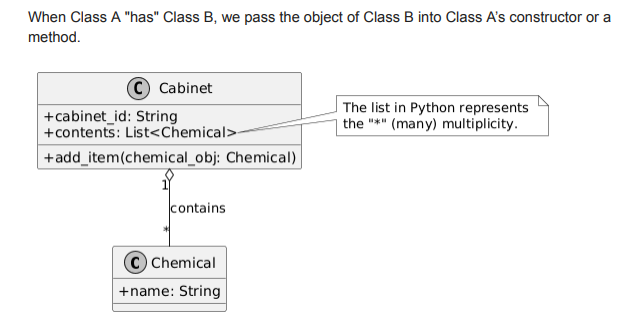

In [ ]:
class Cabinet:
  def __init__(self, cabinet_id):
    self.cabinet_id = cabinet_id
    self.contents = []  # list of chemicals

  def add_item(self, chemical):
    self.contents.append(chemical)
    print(f"{chemical.name} added to cabinet {self.cabinet_id}")

  def remove_item(self, chemical):
    self.contents.remove(chemical)
    print(f"{chemical.name} removed from cabinet {self.cabinet_id}")


class Chemical:
  def __init__(self, name):
    self.name = name



# --- The Relationship in Action ---
acid = Chemical("Hydrochloric Acid") #
storage = Cabinet("C-101") #
storage.add_item(acid) # Passing one object into another!

Hydrochloric Acid added to cabinet C-101


# Activity 1: Lab Manager Sprint (30 minutes)

## The Goal
Create a relationship where a Technician object "has a" Lab object, then access the lab's
data through the technician.

## Step-by-Step Instructions
1. Define the Lab: Create a Lab class that takes a room_number during initialization.
2. Define the Technician: Create a Technician class with a name. Add an attribute
called assigned_lab and set it to None at first.
3. The "Hand-off" Method: Inside Technician, create a method called
assign_lab(self, lab_obj). This method should take a Lab object as a
parameter and store it in self.assigned_lab.
4. Test the Relationship:
- ○ Create a Lab object (e.g., chem_lab = Lab("302")).
- ○ Create a Technician object (e.g., mr_cruz = Technician("Mr. Cruz")).
- ○ Assign the lab: mr_cruz.assign_lab(chem_lab).
5. The Final Print: Print the room number using "Double Dot" access:
print(mr_cruz.assigned_lab.room_number).

> 💡 Pro-Tip: If you see AttributeError: 'NoneType' has no attribute
'room_number', it means you tried to check the room before you gave the
Technician the "keycard"! Make sure you call your assignment method first.

In [ ]:
class Lab:
  def __init__(self, room_number):
    self.room_number = room_number

  def __repr__(self):
    return f"Lab #{self.room_number}"


class Technician:
  def __init__(self, name):
    self.name = name
    self.assigned_lab = None

  def assign_lab(self, lab_obj):
    self.assigned_lab = lab_obj
    print(f"{self.assigned_lab} is assigned to {self.name}")


# let's test

chem_lab = Lab("302")
mr_cruz = Technician("Mr. Cruz")
mr_cruz.assign_lab(chem_lab)
print(f"The room is {mr_cruz.assigned_lab.room_number}")

Lab #302 is assigned to Mr. Cruz
The room is 302


#  Activity 2: Real-Life Relationship Mapping (10 minutes)

**Scenario**: You are mapping out a School Management System.
1. Make classes for Course and Student.
2. Note the multiplicity (e.g., 1 Course can have * Students).
3. Write a short Python snippet showing a Course adding a Student instance to a list.
4. Add another Student instance to the Course student list
5. Print the course and see if both students show up.

In [ ]:
class Course:
  def __init__(self, course_name):
    self.course_name = course_name
    self.students = []

  def __repr__(self):
    return f"{self.course_name}, Students:{self.students}"

  def add_student(self, student_obj):
    self.students.append(student_obj)

class Student:
  def __init__(self, name):
    self.name = name

  def __repr__(self):
    return f"{self.name}"

# let's test
c = Course("math")
s1 = Student("Ally")
s2 = Student("Cora")
c.add_student(s1)
c.add_student(s2)
print(c)

math, Students:[Ally, Cora]


# SG 7

# Inheritance

### Lesson 2-4 - exactly one to at most one association

### One-to-at-most-one association: Person and Passport

In a one-to-at-most-one association, an instance of one class is related to at most one instance of another class. A common example is a `Person` and a `Passport`: a person can have at most one passport, and a passport belongs to exactly one person.

In [ ]:
class Passport:
  def __init__(self, passport_number, expiration_date, country, owner = None):
    self.passport_number = passport_number
    self.expiration_date = expiration_date
    self.country = country
    self.owner = owner # A passport belongs to at most one person

    if self.owner:
      self.owner.assign_passport(self)


  def __repr__(self):
    owner_name = self.owner.name if self.owner else "No owner"
    return f"Passport('{self.passport_number}', '{self.expiration_date}', '{self.country}', owner='{owner_name}')"


class Person:
  def __init__(self, name, age):
    self.name = name
    self.age = age
    self.passport = None  # A person can have at most one passport

  def assign_passport(self, passport):
    if not isinstance(passport, Passport):
      print("Invalid passport object provided.")
      return

    # Check if the passport is already assigned to someone else
    if passport.owner and passport.owner is not self:
      print(f"Error: Passport {passport.passport_number} is already assigned to {passport.owner.name}.")
      return

    self.passport = passport
    passport.owner = self
    print(f"{self.name} has been assigned passport {passport.passport_number}.")



  def get_details(self):
    details = f"Name: {self.name}, Age: {self.age}"
    if self.passport:
      details += f", {self.passport}"
    else:
      details += ", No passport assigned."
    return details

  def __repr__(self):
    return self.get_details()

### Demonstration of Person and Passport classes

In [ ]:
# Create some person objects
alice = Person("Alice", 30)
bob = Person("Bob", 25)
charlie = Person("Charlie", 40)

# Create some passport objects
passport_alice = Passport("AB123456", "2030-12-31", "USA", alice)

passport_bob = Passport("CD789012", "2028-06-15", "Canada", bob)
passport_unassigned = Passport("EF345678", "2029-01-01", "Germany")


print("\n--- Initial State ---")
print(str(alice))
print(alice)
alice
print(bob)
print(charlie)
print(passport_alice)
print(passport_bob)
print(passport_unassigned)


# Try assigning an unassigned passport
print("\n--- Assigning unassigned passport ---")
alice.assign_passport(passport_unassigned) # Alice gets a new passport, her old one is unassigned

# Display details after reassignment
print("\n--- After Reassignment ---")
print(alice)
print(bob)
print(charlie)
print(passport_alice) # Should now be unowned
print(passport_bob)
print(passport_unassigned) # Should now be owned by Alice



Alice has been assigned passport AB123456.
Bob has been assigned passport CD789012.

--- Initial State ---
Name: Alice, Age: 30, Passport('AB123456', '2030-12-31', 'USA', owner='Alice')
Name: Alice, Age: 30, Passport('AB123456', '2030-12-31', 'USA', owner='Alice')
Name: Bob, Age: 25, Passport('CD789012', '2028-06-15', 'Canada', owner='Bob')
Name: Charlie, Age: 40, No passport assigned.
Passport('AB123456', '2030-12-31', 'USA', owner='Alice')
Passport('CD789012', '2028-06-15', 'Canada', owner='Bob')
Passport('EF345678', '2029-01-01', 'Germany', owner='No owner')

--- Assigning unassigned passport ---
Alice has been assigned passport EF345678.

--- After Reassignment ---
Name: Alice, Age: 30, Passport('EF345678', '2029-01-01', 'Germany', owner='Alice')
Name: Bob, Age: 25, Passport('CD789012', '2028-06-15', 'Canada', owner='Bob')
Name: Charlie, Age: 40, No passport assigned.
Passport('AB123456', '2030-12-31', 'USA', owner='Alice')
Passport('CD789012', '2028-06-15', 'Canada', owner='Bob')


### Inheritance and One-to-Many Association: Teacher and Student

Now, let's explore inheritance by creating a `Teacher` class that inherits from our `Person` class. We'll also define a `Student` class, which will also inherit from `Person`, and establish a one-to-many relationship where a `Teacher` can have multiple `Students`.

In [ ]:
class Student(Person):
  def __init__(self, name, age, student_id):
    super().__init__(name, age) # Initialize attributes from the Person class
    self.student_id = student_id

  # Override get_details to include student-specific information
  def get_details(self):
    person_details = super().get_details() # Get details from the Person class
    return f"{person_details.replace(', No passport assigned.', '')}, ID: {self.student_id}"


class Teacher(Person):
  def __init__(self, name, age, employee_id, subject):
    super().__init__(name, age) # Initialize attributes from the Person class
    self.employee_id = employee_id
    self.subject = subject
    self.students = [] # A teacher can have 0 or more students

  def add_student(self, student):

    if not isinstance(student, Student):
      print("Invalid student object provided.")
      return

    if student in self.students:
      print(f"{student.name} is already in {self.name}'s class.")
      return

    self.students.append(student)
    print(f"{student.name} added to {self.name}'s class.")


  def remove_student(self, student):
    if student in self.students:
      self.students.remove(student)
      print(f"{student.name} removed from {self.name}'s class")
    else:
      print(f"{student.name} isn't in {self.name}'s class")



  # Override the get_details method to include teacher-specific information and students
  def get_details(self):
    person_details = super().get_details() # Get details from the Person class
    teacher_details = f"Employee ID: {self.employee_id}, Subject: {self.subject}"
    student_names = [s.name for s in self.students]
    students_info = f"Students: {', '.join(student_names) if student_names else 'None'}"
    return f"{person_details}, {teacher_details}, {students_info}"


### Demonstration of Teacher and Student Classes

In [ ]:
# Create some student objects
student1 = Student("Eve", 16, "S001")
student2 = Student("Frank", 17, "S002")
student3 = Student("Grace", 16, "S003")

# Create a teacher object (inheriting from Person, so it can also have passports)
teach_sara = Teacher("Ms. Sara", 35, "T001", "Math")
teach_john = Teacher("Mr. John", 40, "T002", "Science")

# Assign a passport to the teacher (demonstrating Person inheritance)
passport_sara = Passport("TEACHER123", "2035-10-20", "UK", teach_sara)

# Assign a passport to a student
passport_eve = Passport("STUDENT456", "2027-05-10", "USA", student1)

print("\n--- Initial State of Teachers and Students ---")
print(teach_sara)
print(teach_john)
print(student1)
print(student2)
print(student3)

# Add students to Ms. Sara's class
print("\n--- Adding Students to Ms. Sara's Class ---")
teach_sara.add_student(student1)
teach_sara.add_student(student2)

# Try adding the same student again
teach_sara.add_student(student1)

# Add student to Mr. John's class
print("\n--- Adding Students to Mr. John's Class ---")
teach_john.add_student(student3)

print("\n--- After Adding Students ---")
print(teach_sara)
print(teach_john)
print(student1) # Student details also reflect their inherited passport


# remove a student
print("\n--- Removing Student from Ms. Sara's Class ---")
teach_sara.remove_student(student1)

# Try removing a non-existent student
teach_sara.remove_student(student1)

Ms. Sara has been assigned passport TEACHER123.
Eve has been assigned passport STUDENT456.

--- Initial State of Teachers and Students ---
Name: Ms. Sara, Age: 35, Passport('TEACHER123', '2035-10-20', 'UK', owner='Ms. Sara'), Employee ID: T001, Subject: Math, Students: None
Name: Mr. John, Age: 40, No passport assigned., Employee ID: T002, Subject: Science, Students: None
Name: Eve, Age: 16, Passport('STUDENT456', '2027-05-10', 'USA', owner='Eve'), ID: S001
Name: Frank, Age: 17, ID: S002
Name: Grace, Age: 16, ID: S003

--- Adding Students to Ms. Sara's Class ---
Eve added to Ms. Sara's class.
Frank added to Ms. Sara's class.
Eve is already in Ms. Sara's class.

--- Adding Students to Mr. John's Class ---
Grace added to Mr. John's class.

--- After Adding Students ---
Name: Ms. Sara, Age: 35, Passport('TEACHER123', '2035-10-20', 'UK', owner='Ms. Sara'), Employee ID: T001, Subject: Math, Students: Eve, Frank
Name: Mr. John, Age: 40, No passport assigned., Employee ID: T002, Subject: Scie

### Inheritance and Bidirectional Association: Parent and Child

Let's now model families with a `Parent` class and a `Child` class, both inheriting from `Person`. This introduces a more complex, bidirectional relationship where a `Child` knows its `mother` and `father`, and a `Parent` keeps track of its `children`.

In [ ]:
class Mother(Person):
  def __init__(self, name, age):
    super().__init__(name, age)
    self.children =[]

  @property
  def is_valid_mother(self):
    return len(self.children) > 0

  def add_child(self, child):
    # check if the child is an instance of the Child class
    if not isinstance(child, Child):
      print(f'Invalid object type. {child.name} is not a Child object. ')
      return
    # check if the child's mother is self
    if not child.mother is self:
      print(f"Child {child.name}'s mother is not {self.name}.")
      return
    # check if child isn't already in the list
    if child in self.children:
      print(f"{child.name} is already listed as {self.name}'s child.")
      return
    # add the child
    self.children.append(child)
    print(f"{child.name} added to {self.name}'s children.")

  def get_details(self):
    person_details = super().get_details()
    children_list = [c.name for c in self.children]
    children_info = f"Children: {', '.join(children_list) if children_list else 'None'}"
    return f"{person_details}, {children_info} "


class Child(Person):
  def __init__(self, name, age, bren, mother):
    super().__init__(name,age)
    self.bren = bren
    if not isinstance(mother, Person):
      raise ValueError("Mother must be an instance of the Person class.")
    self.mother = mother

    # check if the mother is a first time mom
    if not isinstance(mother, Mother):
      m = Mother(mother.name, mother.age, self)
      m.passport = mother.passport
      self.mother = m
      m.add_child(self)
      mother = m
    else:
      mother.add_child(self)



  def get_details(self):
    person_details = super().get_details().replace(', No passport assigned.', '')
    return f"{person_details}, BReN: {self.bren}, mother: {self.mother}"


### Demonstration of Parent and Child Classes

Here's how these classes interact to model a family structure.

In [ ]:
sarah = Mother("Sarah Connor", 45)

# Create Child instances
john_jr = Child("John Connor Jr.", 20, "BREN-001", sarah)
jane = Child("Jane Connor", 15, "BREN-002", mother=sarah)




print("\n--- Initial Family State ---")
print(sarah)
print(john_jr)
print(jane)

# Assign a passport to a parent
passport_sarah = Passport("PNT789", "2033-07-01", "USA")
sarah.assign_passport(passport_sarah)

# Assign a passport to a child
passport_johnjr = Passport("CHD101", "2028-01-15", "USA")
john_jr.assign_passport(passport_johnjr)

print("\n--- After Passport Assignments ---")
print(sarah)
print(john_jr)




John Connor Jr. added to Sarah Connor's children.
Jane Connor added to Sarah Connor's children.

--- Initial Family State ---
Name: Sarah Connor, Age: 45, No passport assigned., Children: John Connor Jr., Jane Connor 
Name: John Connor Jr., Age: 20, BReN: BREN-001, mother: Name: Sarah Connor, Age: 45, No passport assigned., Children: John Connor Jr., Jane Connor 
Name: Jane Connor, Age: 15, BReN: BREN-002, mother: Name: Sarah Connor, Age: 45, No passport assigned., Children: John Connor Jr., Jane Connor 
Sarah Connor has been assigned passport PNT789.
John Connor Jr. has been assigned passport CHD101.

--- After Passport Assignments ---
Name: Sarah Connor, Age: 45, Passport('PNT789', '2033-07-01', 'USA', owner='Sarah Connor'), Children: John Connor Jr., Jane Connor 
Name: John Connor Jr., Age: 20, Passport('CHD101', '2028-01-15', 'USA', owner='John Connor Jr.'), BReN: BREN-001, mother: Name: Sarah Connor, Age: 45, Passport('PNT789', '2033-07-01', 'USA', owner='Sarah Connor'), Children:

# Composition

- A Microscope has a Lens.
- It is already inside it and isn't placed in by the user.
- When the Microscope is destroyed, the lens is also destroyed with it.

In [ ]:
class Microscope:
  def __init__(self, model):
    self.model = model
    self.lens = Lens(power=40)

  def __repr__(self):
    return f"Microscope(model={self.model}, magnification={self.lens.power})"

  def view(self):
    print(f"Viewing using {self.model} at {self.lens.power}x magnification.")



class Lens:

  def __init__(self, power):
    self.power = power

  def __repr__(self):
    return f"Lens has {self.power}x magnification."



In [ ]:
m = Microscope("zoom1000")
print(m)
m.view()
print(m.lens)
l = m.lens
print(l)
del m
print(l)

Microscope(model=zoom1000, magnification=40)
Viewing using zoom1000 at 40x magnification.
Lens has 40x magnification.
Lens has 40x magnification.
Lens has 40x magnification.


## This shows Composition

1. Creation: The Microscope creates the Lens inside its own __init__. The user
doesn't pass a lens in; the microscope "is born" with it.
2. Ownership: The Lens belongs strictly to that specific Microscope.
3. Lifecycle (The Death Test): When the Microscope object is deleted (del
my_scope), the Lens object is also wiped from the computer's memory.
4. UML Notation: This matches the Filled Diamond symbol.

# Inheritance

 A DigitalMicroscope is a Microscope. It inherits all the lenses of a standard
microscope but adds a "Digital Sensor."

In [ ]:


class DigitalMicroscope(Microscope):
  def __init__(self, model, sensor_resolution):
    super().__init__(model)
    self.sensor_resolution = sensor_resolution

  def __repr__(self):
    microscope_repr = super().__repr__()
    return f"{microscope_repr} The sensor resolution is {self.sensor_resolution}."

  def capture_image(self):
    print(f"Capturing image at {self.sensor_resolution} resolution")

  def record_video(self):
      print(f"Recording video..")

In [ ]:
print('--- Demonstrating Microscope ---')
standard_microscope = Microscope("zoom1000")
print(standard_microscope)
standard_microscope.view()

print('\n--- Demonstrating DigitalMicroscope ---')
digital_scope = DigitalMicroscope(model="zoomAI", sensor_resolution='1080p')
print(digital_scope)
digital_scope.view()
digital_scope.capture_image()
digital_scope.record_video()

--- Demonstrating Microscope ---
Microscope(model=zoom1000, magnification=40)
Viewing using zoom1000 at 40x magnification.

--- Demonstrating DigitalMicroscope ---
Microscope(model=zoomAI, magnification=40) The sensor resolution is 1080p.
Viewing using zoomAI at 40x magnification.
Capturing image at 1080p resolution
Recording video..


## The `super()` Command
● super(): A proxy object that delegates method calls to a parent or sibling class of type. It
ensures that the base class is properly initialized.



# Aggregation

- A laboratory has a microscope
- But even if the laboratory closes down, the microscope is still ok

In [ ]:
class Lab:
  def __init__(self, name, microscope=None):
    self.name = name

    if not isinstance(microscope, Microscope):
      raise ValueError('The research lab must have a microscope.')
      return
    self.microscope = microscope
    print(f'The {self.name} lab is created with {self.microscope} inside')

  def __repr__(self):
    return f"The {self.name} lab has {self.microscope}"

  def research(self):
    print(f'Students are researching in {self.name} lab.')
    self.microscope.view()

  def __del__(self):
    print('The lab has permanently closed down')
    print('You might want to keep using the microscope though.')



# demo usage
# help(Lab)
# help(Microscope)
# help(DigitalMicroscope)
scope1 = Microscope("zoomzoom123")
scope2 = DigitalMicroscope("digizoom321", 720)
lab1 = Lab("ResLab1", scope1)
print(lab1)
lab1.microscope = scope2
print(lab1)
del lab1
print(scope1)
print(scope2)
try:
  print(lab1)
except:
  print('lab1 has been deleted')

The ResLab1 lab is created with Microscope(model=zoomzoom123, magnification=40) inside
The ResLab1 lab has Microscope(model=zoomzoom123, magnification=40)
The ResLab1 lab has Microscope(model=digizoom321, magnification=40) The sensor resolution is 720.
The lab has permanently closed down
You might want to keep using the microscope though.
Microscope(model=zoomzoom123, magnification=40)
Microscope(model=digizoom321, magnification=40) The sensor resolution is 720.
lab1 has been deleted


## This Shows Aggregation
- ● The Microscope is created outside the Lab.
- ● The Lab just references the Microscope — it doesn’t own its lifetime.
- ● When the Lab is deleted, the Microscope still exists and can be used.
- ● This matches the hollow diamond aggregation symbol in UML.

Let's reuse the Passport and Person classes

In [ ]:
class Passport:
  def __init__(self, passport_number, expiration_date, country, owner = None):
    self.passport_number = passport_number
    self.expiration_date = expiration_date
    self.country = country
    self.owner = owner # A passport belongs to at most one person

    if self.owner:
      self.owner.assign_passport(self)


  def __repr__(self):
    owner_name = self.owner.name if self.owner else "No owner"
    return f"Passport('{self.passport_number}', '{self.expiration_date}', '{self.country}', owner='{owner_name}')"


class Person:
  def __init__(self, name, age):
    self.name = name
    self.age = age
    self.passport = None  # A person can have at most one passport

  def assign_passport(self, passport):
    if not isinstance(passport, Passport):
      print("Invalid passport object provided.")
      return

    # Check if the passport is already assigned to someone else
    if passport.owner and passport.owner is not self:
      print(f"Error: Passport {passport.passport_number} is already assigned to {passport.owner.name}.")
      return

    self.passport = passport
    passport.owner = self
    print(f"{self.name} has been assigned passport {passport.passport_number}.")



  def get_details(self):
    details = f"Name: {self.name}, Age: {self.age}"
    if self.passport:
      details += f", {self.passport}"
    else:
      details += ", No passport assigned."
    return details

  def __repr__(self):
    return self.get_details()

Now let's make a Scientist class that reuses the Person class. Then let's have a Scientist use a Microscope

In [ ]:
class Scientist(Person):
  def __init__(self, name, age):
    super().__init__(name,age)
    print(f'Scientist {self.name} is ready to conduct research.')

  def conduct_research(self, microscope):
    if not isinstance(microscope, Microscope):
      print(f"Error: {type(microscope).__name__} is not a valid microscope for research.")
      return

    microscope.view()
    print(f"{self.name} is conducting research with {microscope}")

# Demo code
print("\n--- Scientist Demo ---")
# Create a scientist
marie = Scientist("Marie Curie", 35)

# Create a microscope (reusing a DigitalMicroscope from earlier context)
digital_scope_for_marie = DigitalMicroscope("🔬AdvancedDigital", 1080)

# Have the scientist conduct research
marie.conduct_research(digital_scope_for_marie)

# Example with a standard microscope
standard_scope_for_marie = Microscope("🔭StandardOptical")
marie.conduct_research(standard_scope_for_marie)


--- Scientist Demo ---
Scientist Marie Curie is ready to conduct research.
Viewing using 🔬AdvancedDigital at 40x magnification.
Marie Curie is conducting research with Microscope(model=🔬AdvancedDigital, magnification=40) The sensor resolution is 1080.
Viewing using 🔭StandardOptical at 40x magnification.
Marie Curie is conducting research with Microscope(model=🔭StandardOptical, magnification=40)


 ## This Shows Dependency
- ● The Scientist does not create or permanently own the Microscope.
- ● Instead, the Scientist just uses it during for a research (conduct_research).
- ● After the research, the Microscope continues to exist independently.
- ● This matches the dashed arrow dependency symbol in UML.

## Summary

- **Composition**: `class Human` $\blacklozenge$--- `class Heart`
- **Aggregation**: `class Lab` $\lozenge$--- `class Laptop`
- **Dependency**: `class Scientist` $\dots\to$ `class Thermometer` (Dashed Line + Arrow)
- **Realization**: `class Battery` $\dots\triangleright$ `class PowerSource` (Dashed Line + Hollow Triangle)
- **Inheritance**: `class Animal` $\triangleleft$--- `class Dog` (Solid Line + Hollow Triangle)

### LaTeX UML Relationship Symbols

You can use these in Markdown cells by wrapping them in dollar signs (`$`).

| Relationship | Symbol | LaTeX Code |
| :--- | :---: | :--- |
| **Composition** | $\blacklozenge$ | `\blacklozenge` |
| **Aggregation** | $\lozenge$ | `\lozenge` |
| **Inheritance** | $\triangleleft$ | `\triangleleft` |
| **Association** | $-$ | `-` (Hyphen) |
| **Dependency** | $\dots\to$ | `\dots\to` |
| **Realization** | $\dots\triangleright$ | `\dots\triangleright` |

# Activity: Code The Lab Inventory Hierarchy

- **Goal**: Implement Inheritance and Composition.

- You need to organize the inventory. A Glassware parent class should exist, and
Beaker should inherit from it.
- Additionally, a Tray should compose 5 Beakers.
- If the Tray is deleted, the Beakers should effectively be "lost" to the system.


In [ ]:
class Glassware:
  def __init__(self, name):
    self.name = name

  def __repr__(self):
    return f"{self.name} glassware"

class Beaker(Glassware):
  def __init__(self, name):
    super().__init__(name)

  def __repr__(self):
    return f"{self.name} beaker"

class Tray:
  def __init__(self):
    self.beakers = []
    for i in range(5):
      self.beakers.append(Beaker(f"B{i+1}"))

  def __repr__(self):
    return f"Tray with {len(self.beakers)} beakers"




In [ ]:
t = Tray()
print(t)
print(t.beakers[0])


Tray with 5 beakers
B1 beaker


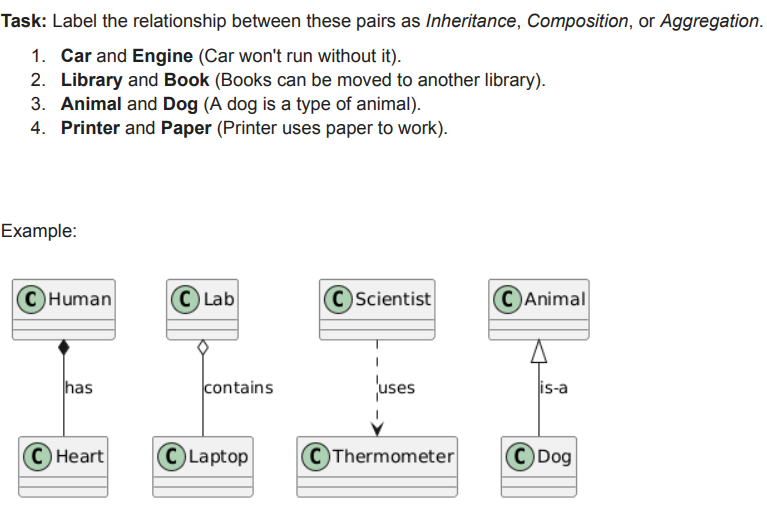